<a href="https://colab.research.google.com/github/Ailsasahda13/DataMining-Semester4/blob/main/Jobsheet%2011%20-%20Clustering%20with%20Python/Tugas%20Iris.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler

from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering

from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    adjusted_rand_score
)

In [2]:
iris = load_iris()

X = iris.data
y_true = iris.target

df = pd.DataFrame(X, columns=iris.feature_names)
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

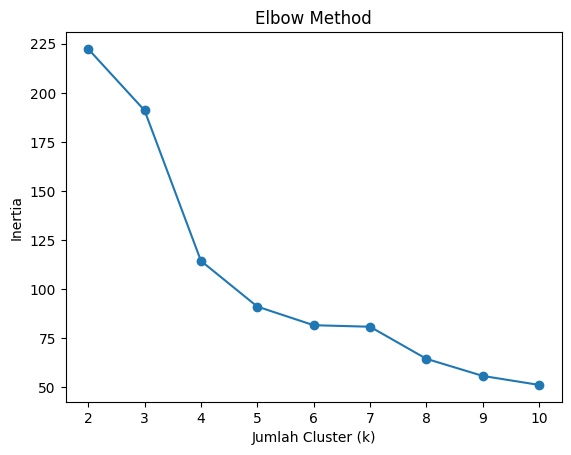

In [6]:
# mencari K-Terbaik
# Elbow Method

inertia = []
K = range(2, 11)

for k in K:
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(X_scaled)
    inertia.append(model.inertia_)

plt.plot(K, inertia, marker='o')
plt.xlabel('Jumlah Cluster (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

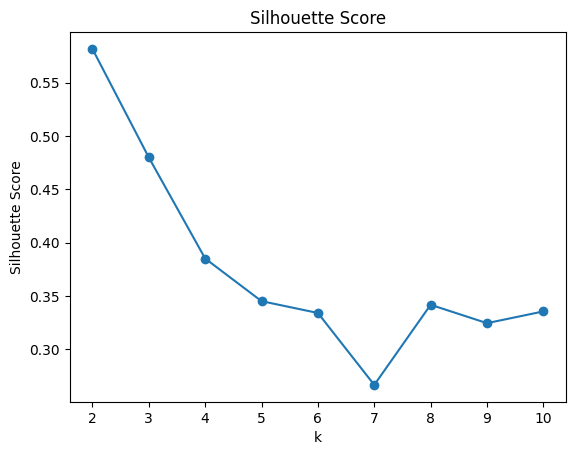

In [7]:
# Mencari K-Terbaik
# Silhoutte

sil_scores = []

for k in range(2, 11):
    model = KMeans(n_clusters=k, random_state=42)
    labels = model.fit_predict(X_scaled)
    sil_scores.append(silhouette_score(X_scaled, labels))

plt.plot(range(2, 11), sil_scores, marker='o')
plt.xlabel('k')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score')
plt.show()

In [8]:
# Clustering K-Means

kmeans = KMeans(n_clusters=3, random_state=42)
labels_kmeans = kmeans.fit_predict(X_scaled)

In [10]:
# Clustering DBSCAN

dbscan = DBSCAN(eps=0.8, min_samples=5)
labels_dbscan = dbscan.fit_predict(X_scaled)

In [12]:
# Clustering Agglomerative

agglo = AgglomerativeClustering(n_clusters=3)
labels_agglo = agglo.fit_predict(X_scaled)

In [13]:
def evaluate(X, labels, y_true=None):
    unique_labels = set(labels)
    if len(unique_labels) > 1:
        sil = silhouette_score(X, labels)
        dbi = davies_bouldin_score(X, labels)
    else:
        sil = np.nan
        dbi = np.nan

    ari = adjusted_rand_score(y_true, labels) if y_true is not None else np.nan

    return sil, dbi, ari

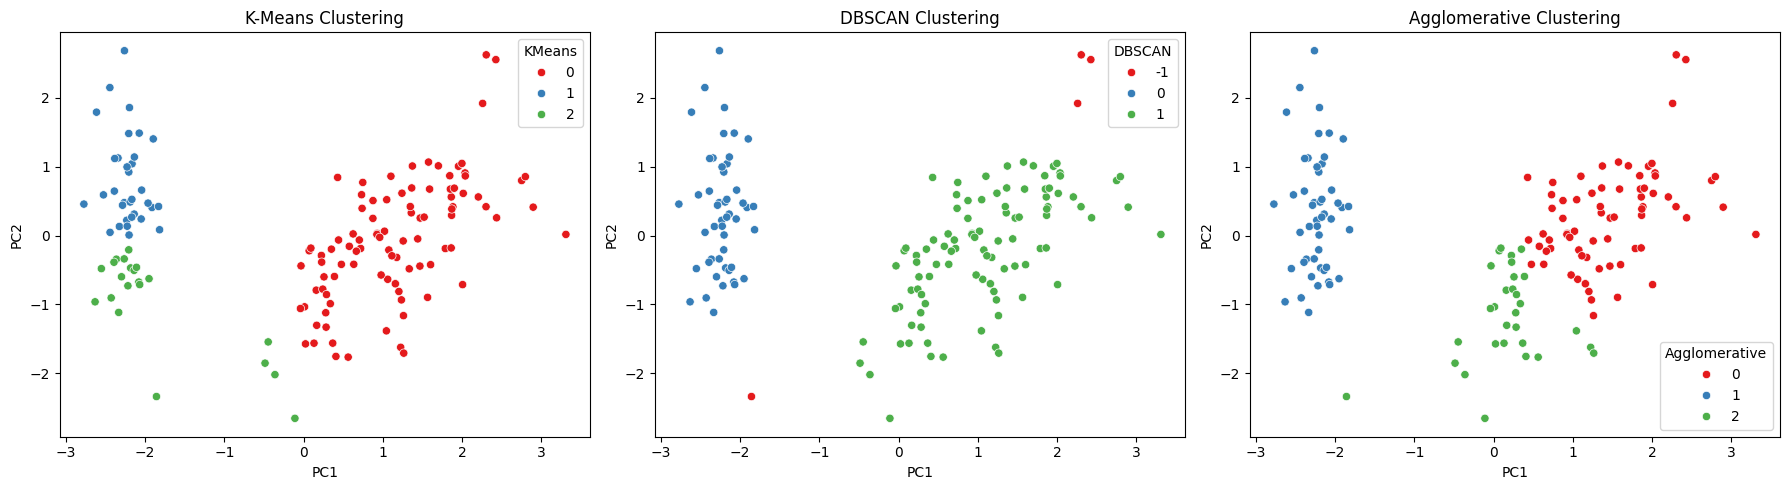

In [15]:
# 9. Visualisasi Scatter Plot Hasil Clustering
# Menggunakan PCA untuk mereduksi 4 fitur Iris menjadi 2 dimensi

from sklearn.decomposition import PCA

# Reduksi dimensi ke 2 komponen
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Tambahkan hasil PCA ke DataFrame
df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])

# Simpan label cluster dari masing-masing metode
df_pca['KMeans'] = labels_kmeans
df_pca['DBSCAN'] = labels_dbscan
df_pca['Agglomerative'] = labels_agglo

# Buat figure dengan 3 subplot
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ----- K-Means -----
sns.scatterplot(
    data=df_pca,
    x='PC1',
    y='PC2',
    hue='KMeans',
    palette='Set1',
    ax=axes[0]
)
axes[0].set_title('K-Means Clustering')

# ----- DBSCAN -----
sns.scatterplot(
    data=df_pca,
    x='PC1',
    y='PC2',
    hue='DBSCAN',
    palette='Set1',
    ax=axes[1]
)
axes[1].set_title('DBSCAN Clustering')

# ----- Agglomerative -----
sns.scatterplot(
    data=df_pca,
    x='PC1',
    y='PC2',
    hue='Agglomerative',
    palette='Set1',
    ax=axes[2]
)
axes[2].set_title('Agglomerative Clustering')

plt.tight_layout()
plt.show()

In [14]:
results = []

for name, labels in [
    ('K-Means', labels_kmeans),
    ('DBSCAN', labels_dbscan),
    ('Agglomerative', labels_agglo)
]:
    sil, dbi, ari = evaluate(X_scaled, labels, y_true)
    results.append([name, sil, dbi, ari])

results_df = pd.DataFrame(
    results,
    columns=['Metode', 'Silhouette', 'Davies-Bouldin', 'ARI']
)

print(results_df)

          Metode  Silhouette  Davies-Bouldin       ARI
0        K-Means    0.479881        0.789363  0.432805
1         DBSCAN    0.521697        1.943201  0.551755
2  Agglomerative    0.446689        0.803467  0.615323
